In [16]:
import kagglehub
path = kagglehub.dataset_download("gillesokhin/nutrition5k-dataset")

Using Colab cache for faster access to the 'nutrition5k-dataset' dataset.


In [17]:
# Cell 0: Kaggle environment setup (run once)
!pip install -q timm albumentations

# standard imports
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [18]:
# Cell 2: Define dataset paths and load CSV
# `path` variable is from the kagglehub.dataset_download in cell 1
ROOT = path
OVERHEAD_DIR = os.path.join(ROOT, "imagery", "realsense_overhead")
CSV_PATH = os.path.join(ROOT, "dish_nutrition_values.csv")

df = pd.read_csv(CSV_PATH)
print("CSV columns:", df.columns.tolist())
print("Example rows:")
display(df.head(3))

CSV columns: ['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']
Example rows:


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593


In [19]:
# Cell 3
# CSV dish_id includes 'dish_' prefix (as you confirmed)
def build_paths(row):
    dish = row['dish_id']  # e.g. 'dish_1561662216'
    folder = os.path.join(OVERHEAD_DIR, dish)
    rgb = os.path.join(folder, "rgb.png")
    depth_color = os.path.join(folder, "depth_color.png")
    return rgb, depth_color

df['rgb_path'], df['depth_color_path'] = zip(*df.apply(build_paths, axis=1))

# Filter rows where both files exist
mask = df['rgb_path'].apply(os.path.exists) & df['depth_color_path'].apply(os.path.exists)
missing = (~mask).sum()
print(f"Found {mask.sum()} dish folders with both rgb.png and depth_color.png ({missing} missing).")
df = df[mask].reset_index(drop=True)
print("Final dataset size:", len(df))
df.head(3)

Found 3243 dish folders with both rgb.png and depth_color.png (1525 missing).
Final dataset size: 3243


,dish_id,calories,mass,fat,carb,protein,rgb_path,depth_color_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...
2,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/kaggle/input/nutrition5k-dataset/imagery/real...,/kaggle/input/nutrition5k-dataset/imagery/real...


In [20]:
# Cell 4
nutrients = ["calories", "mass", "fat", "carb", "protein"]
# create bin columns e.g. calories_bin with labels 0,1,2 (3 quantile bins)
for col in nutrients:
    # If there are any NaNs, drop them first (or fill as you prefer)
    df = df[df[col].notna()]
    df[col + "_bin"] = pd.qcut(df[col], 3, labels=[0,1,2]).astype(int)

label_cols = [c + "_bin" for c in nutrients]   # e.g. ['calories_bin', ...]
print("Label columns:", label_cols)
display(df[[ 'dish_id'] + nutrients + label_cols].head(3))


Label columns: ['calories_bin', 'mass_bin', 'fat_bin', 'carb_bin', 'protein_bin']


,dish_id,calories,mass,fat,carb,protein,calories_bin,mass_bin,fat_bin,carb_bin,protein_bin
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,1,1,1,2,1
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,2,2,2,2,2
2,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,2,2,2,1,2


In [21]:
# Cell 5
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))

Train: 2756 Val: 487


In [22]:
# Cell 6
class Nutrition5kDataset(Dataset):
    def __init__(self, df, label_cols, transforms=None):
        self.df = df
        self.label_cols = label_cols
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rgb = np.array(Image.open(row['rgb_path']).convert("RGB"))
        depth_color = np.array(Image.open(row['depth_color_path']).convert("RGB"))

        # Both are H x W x 3 arrays. Pass them to albumentations as two images.
        if self.transforms:
            augmented = self.transforms(image=rgb, depth=depth_color)
            rgb_t = augmented['image']
            depth_t = augmented['depth']
            # Correct: Concatenate along the channel dimension (dim=0 for CHW tensors)
            stacked_tensor = torch.cat([rgb_t, depth_t], dim=0)
        else:
            # if no transforms, convert to tensor-like numpy arrays and transpose manually
            rgb_t = rgb.astype(np.float32) / 255.0
            depth_t = depth_color.astype(np.float32) / 255.0
            # Concatenate HWC numpy arrays, then transpose to CHW tensor
            stacked_np = np.concatenate([rgb_t, depth_t], axis=2)
            stacked_tensor = torch.from_numpy(np.transpose(stacked_np, (2,0,1)))

        labels = torch.tensor(row[self.label_cols].values.astype(np.int64))
        return stacked_tensor, labels

In [23]:
# Cell 7
train_transforms = A.Compose([
    A.Resize(320, 320),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.08, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], additional_targets={'depth': 'image'})

val_transforms = A.Compose([
    A.Resize(320, 320),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], additional_targets={'depth': 'image'})

train_ds = Nutrition5kDataset(train_df, label_cols, transforms=train_transforms)
val_ds   = Nutrition5kDataset(val_df, label_cols, transforms=val_transforms)

BATCH_SIZE = 16   # change depending on GPU memory
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# quick shape sanity check
x, y = next(iter(train_loader))
print("batch images shape:", x.shape)   # should be (B, 6, H, W)
print("batch labels shape:", y.shape)   # (B, num_nutrients)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


batch images shape: torch.Size([16, 6, 320, 320])
batch labels shape: torch.Size([16, 5])


### Define Hybrid Model

In [29]:
class HybridModel(nn.Module):
    def __init__(self, model_name1, model_name2, num_outputs, in_chans=3, pretrained=True):
        super().__init__()
        # Load first backbone model (MobileNetV3)
        self.backbone1 = timm.create_model(model_name1, pretrained=pretrained, in_chans=in_chans)
        # Replace the original classifier with an identity layer to extract features
        self.backbone1.classifier = nn.Identity()

        # Load second backbone model (EfficientNetB0)
        # EfficientNet in timm typically uses 'classifier' as the head
        self.backbone2 = timm.create_model(model_name2, pretrained=pretrained, in_chans=in_chans)
        # Replace the original classifier with an identity layer to extract features
        self.backbone2.classifier = nn.Identity()

        # Dynamically determine the output feature size after Identity() is set
        # Create a dummy input for shape inference, assuming input size 320x320 from A.Resize
        dummy_input = torch.randn(1, in_chans, 320, 320)

        with torch.no_grad():
            features1_dummy = self.backbone1(dummy_input)
            features2_dummy = self.backbone2(dummy_input)

        self.backbone1_output_features = features1_dummy.shape[1]
        self.backbone2_output_features = features2_dummy.shape[1]

        # Combined features for the new head
        combined_features = self.backbone1_output_features + self.backbone2_output_features
        print(f"Backbone1 ({model_name1}) actual output features: {self.backbone1_output_features}")
        print(f"Backbone2 ({model_name2}) actual output features: {self.backbone2_output_features}")
        print(f"Combined actual features: {combined_features}")

        # New classification head
        self.classifier = nn.Linear(combined_features, num_outputs)

    def forward(self, x):
        # Pass input through both backbones
        features1 = self.backbone1(x)
        features2 = self.backbone2(x)

        # Concatenate features
        combined = torch.cat((features1, features2), dim=1)

        # Pass through the new classifier
        output = self.classifier(combined)
        return output

In [30]:
num_nutrients = len(nutrients)       # 5 in your CSV
num_bins = 3
num_outputs = num_nutrients * num_bins  # e.g. 5*3 = 15

model = HybridModel(model_name1='mobilenetv3_large_100', model_name2='efficientnet_b0', num_outputs=num_outputs, in_chans=6)
model = model.to(device)
print(model)

Backbone1 (mobilenetv3_large_100) actual output features: 1280
Backbone2 (efficientnet_b0) actual output features: 1280
Combined actual features: 2560
HybridModel(
  (backbone1): MobileNetV3(
    (conv_stem): Conv2d(6, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Hardswish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (bn1): BatchNormAct2d(
            16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (aa): Identity()
          (se): Identity()
          (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNormAct2d(

In [31]:
# Cell 9
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

In [32]:
# Cell 10
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc="train", leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)   # shape B x num_nutrients

        optimizer.zero_grad()
        logits = model(imgs)         # shape B x (num_nutrients*num_bins)
        # reshape to (B, num_nutrients, num_bins)
        logits_r = logits.view(-1, num_nutrients, num_bins)

        # compute sum of CE across nutrients
        loss = sum(criterion(logits_r[:, i], labels[:, i]) for i in range(num_nutrients))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader.dataset)

def compute_map(model, loader, device):
    model.eval()
    all_probs = []
    all_onehot = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)   # B x (N*num_bins)
            # reshape and softmax per nutrient
            logits_r = logits.view(-1, num_nutrients, num_bins).cpu().numpy()
            probs = np.softmax(logits_r, axis=2) if hasattr(np, 'softmax') else np.exp(logits_r)/np.sum(np.exp(logits_r), axis=2, keepdims=True)
            # probs shape B x N x num_bins

            # flatten probs to B x (N*num_bins)
            B = probs.shape[0]
            probs_flat = probs.reshape(B, -1)
            all_probs.append(probs_flat)

            # build one-hot true labels per bin
            lab = labels.numpy()  # B x N
            onehot = np.zeros_like(probs_flat, dtype=np.int32)  # B x (N*num_bins)
            for i in range(num_nutrients):
                # for nutrient i, set column i*num_bins + true_bin = 1
                idx = lab[:, i].astype(int)
                cols = i * num_bins + idx
                onehot[np.arange(B), cols] = 1
            all_onehot.append(onehot)

    y_score = np.vstack(all_probs)
    y_true = np.vstack(all_onehot)

    # compute AP per flattened class (i.e., each bin for each nutrient)
    ap_list = []
    for c in range(y_true.shape[1]):
        # skip classes with no positive examples in val set
        if y_true[:, c].sum() == 0:
            ap_list.append(np.nan)
            continue
        try:
            ap = average_precision_score(y_true[:, c], y_score[:, c])
            ap_list.append(ap)
        except ValueError:
            ap_list.append(np.nan)

    ap_array = np.array(ap_list, dtype=np.float32)
    mean_ap = np.nanmean(ap_array)
    return mean_ap, ap_array.reshape(num_nutrients, num_bins)

In [34]:
from tqdm.autonotebook import tqdm

# Cell 11
EPOCHS = 20
best_map = 0.0

for epoch in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_map, ap_table = compute_map(model, val_loader, device)
    scheduler.step(val_map)

    print(f"Epoch {epoch}/{EPOCHS} — Train loss: {train_loss:.4f} | Val mAP: {val_map:.4f}")
    # print per-nutrient AP (3 bins each)
    for i, nutrient in enumerate(nutrients):
        print(f"  {nutrient}: AP per bin = {ap_table[i].round(4).tolist()}")
    # save best
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), "best_effnet6ch_nutrition5k.pth")
        print("  Saved best model with mAP:", best_map)

train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 1/20 — Train loss: 0.5220 | Val mAP: 0.8675
  calories: AP per bin = [0.9423999786376953, 0.7200999855995178, 0.888700008392334]
  mass: AP per bin = [0.9544000029563904, 0.843999981880188, 0.9537000060081482]
  fat: AP per bin = [0.9276999831199646, 0.7089999914169312, 0.9032999873161316]
  carb: AP per bin = [0.8626000285148621, 0.7034000158309937, 0.8813999891281128]
  protein: AP per bin = [0.9564999938011169, 0.8256999850273132, 0.9394000172615051]
  Saved best model with mAP: 0.8674882


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 2/20 — Train loss: 0.4651 | Val mAP: 0.8575
  calories: AP per bin = [0.9520000219345093, 0.7010999917984009, 0.8704000115394592]
  mass: AP per bin = [0.9542999863624573, 0.8288999795913696, 0.9528999924659729]
  fat: AP per bin = [0.940500020980835, 0.7224000096321106, 0.8819000124931335]
  carb: AP per bin = [0.8641999959945679, 0.6201000213623047, 0.8564000129699707]
  protein: AP per bin = [0.965499997138977, 0.8223999738693237, 0.9291999936103821]


train:   0%|          | 0/173 [00:00<?, ?it/s]

...

Epoch 18/20 — Train loss: 0.0516 | Val mAP: 0.8857
  calories: AP per bin = [0.9541000127792358, 0.7452999949455261, 0.9266999959945679]
  mass: AP per bin = [0.9646000266075134, 0.8657000064849854, 0.9541000127792358]
  fat: AP per bin = [0.949999988079071, 0.7616000175476074, 0.9214000105857849]
  carb: AP per bin = [0.8801000118255615, 0.6872000098228455, 0.892300009727478]
  protein: AP per bin = [0.9671000242233276, 0.8741000294685364, 0.9406999945640564]


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 19/20 — Train loss: 0.0504 | Val mAP: 0.8871
  calories: AP per bin = [0.9559999704360962, 0.7570000290870667, 0.9264000058174133]
  mass: AP per bin = [0.9657999873161316, 0.8652999997138977, 0.954200029373169]
  fat: AP per bin = [0.9506999850273132, 0.7623999714851379, 0.9248999953269958]
  carb: AP per bin = [0.8787999749183655, 0.6894000172615051, 0.8931999802589417]
  protein: AP per bin = [0.9685999751091003, 0.8727999925613403, 0.9416000247001648]
  Saved best model with mAP: 0.8871221


train:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 20/20 — Train loss: 0.0407 | Val mAP: 0.8858
  calories: AP per bin = [0.955299973487854, 0.7427999973297119, 0.9262999892234802]
  mass: AP per bin = [0.965499997138977, 0.8641999959945679, 0.9567999839782715]
  fat: AP per bin = [0.9498999714851379, 0.7597000002861023, 0.9253000020980835]
  carb: AP per bin = [0.8787999749183655, 0.6887000203132629, 0.8899999856948853]
  protein: AP per bin = [0.9679999947547913, 0.8758999705314636, 0.9397000074386597]


In [35]:
# Cell 12
model.load_state_dict(torch.load("best_effnet6ch_nutrition5k.pth", map_location=device))
model.eval()

imgs, labels = next(iter(val_loader))
with torch.no_grad():
    logits = model(imgs.to(device))
    logits_r = logits.view(-1, num_nutrients, num_bins)
    probs = torch.softmax(logits_r, dim=2).cpu().numpy()   # B x N x bins

# show first sample predicted bin and probabilities
sample_idx = 0
pred_bins = probs[sample_idx].argmax(axis=1)
print("True bins:", labels[sample_idx].numpy())
print("Pred bins:", pred_bins)
print("Pred probs (per nutrient):")
for i, nutrient in enumerate(nutrients):
    print(f"  {nutrient}: {probs[sample_idx, i].round(4)}")


True bins: [2 2 2 1 2]
Pred bins: [2 2 2 1 2]
Pred probs (per nutrient):
  calories: [0.     0.0056 0.9944]
  mass: [0.000e+00 1.000e-04 9.998e-01]
  fat: [0.000e+00 1.000e-04 9.998e-01]
  carb: [0.0087 0.9281 0.0632]
  protein: [1.000e-04 2.000e-04 9.997e-01]


In [36]:
all_true_bins = []
all_pred_probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        logits_r = logits.view(-1, num_nutrients, num_bins)  # B x N x bins
        probs = torch.softmax(logits_r, dim=2).cpu().numpy()

        # convert true labels to bins
        # assuming labels are already discretized to bins; if not, discretize here
        true_bins = labels.numpy().astype(int)

        all_true_bins.append(true_bins)
        all_pred_probs.append(probs)

all_true_bins = np.vstack(all_true_bins)      # shape: val_size x N
all_pred_probs = np.vstack(all_pred_probs)    # shape: val_size x N x bins


In [37]:
from sklearn.metrics import average_precision_score

mAP_per_nutrient = []

for i in range(num_nutrients):
    # One-hot encode the true labels
    true_one_hot = np.eye(num_bins)[all_true_bins[:, i]]  # val_size x bins

    # Compute average precision for this nutrient
    ap = average_precision_score(true_one_hot, all_pred_probs[:, i, :], average='macro')
    mAP_per_nutrient.append(ap)

# Print results
for i, nutrient in enumerate(nutrients):
    print(f"{nutrient} mAP: {mAP_per_nutrient[i]:.4f}")

print(f"Mean mAP across all nutrients: {np.mean(mAP_per_nutrient):.4f}")

calories mAP: 0.8798
mass mAP: 0.9284
fat mAP: 0.8795
carb mAP: 0.8205
protein mAP: 0.9276
Mean mAP across all nutrients: 0.8872


In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [39]:
def plot_sample_prediction(sample_idx, nutrients, true_bins, pred_probs):
    """
    sample_idx : int, index of the sample to plot
    nutrients : list of nutrient names
    true_bins : array, shape (num_samples, num_nutrients)
    pred_probs : array, shape (num_samples, num_nutrients, num_bins)
    """
    num_nutrients = len(nutrients)
    num_bins = pred_probs.shape[2]

    fig, axes = plt.subplots(1, num_nutrients, figsize=(4*num_nutrients, 4))

    for i, ax in enumerate(axes):
        bins = np.arange(num_bins)
        ax.bar(bins, pred_probs[sample_idx, i], color='skyblue', alpha=0.7, label='Predicted Prob')
        ax.axvline(true_bins[sample_idx, i], color='red', linestyle='--', label='True Bin')
        ax.set_title(nutrients[i])
        ax.set_xlabel("Bins")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1)
        ax.legend()

    plt.tight_layout()
    plt.show()

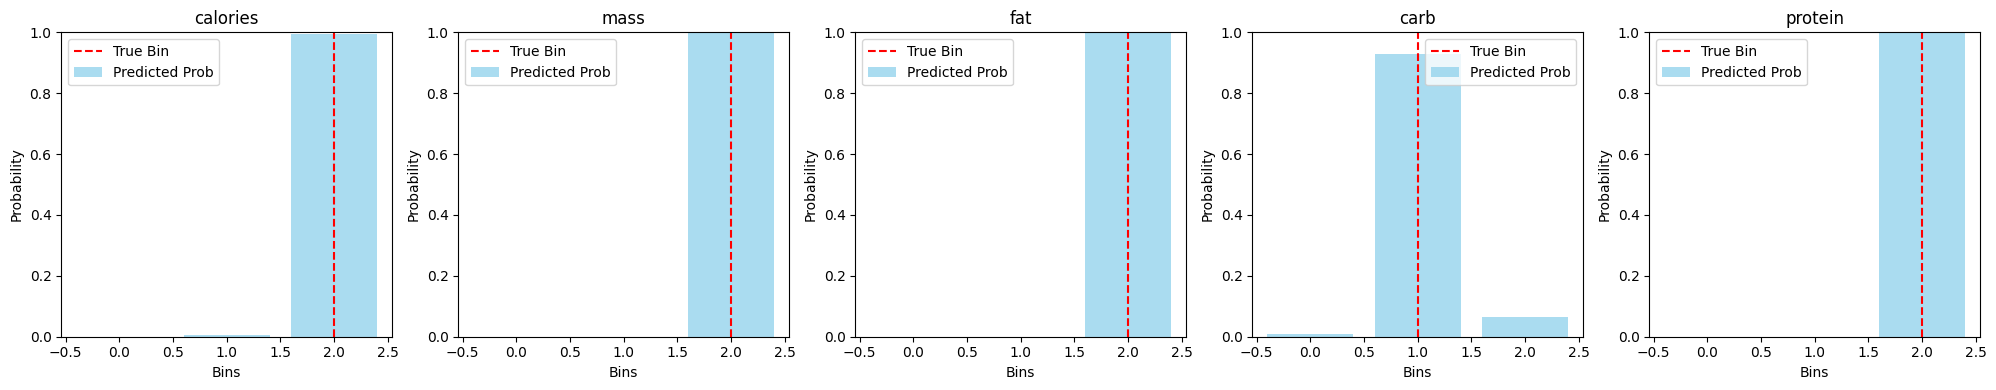

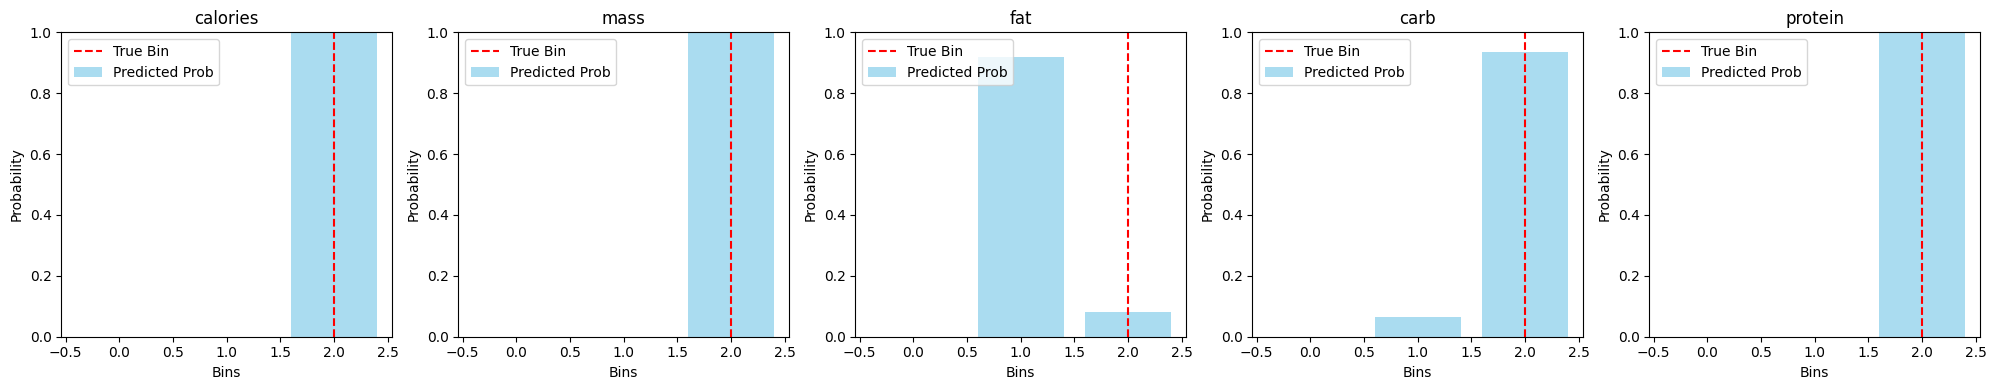

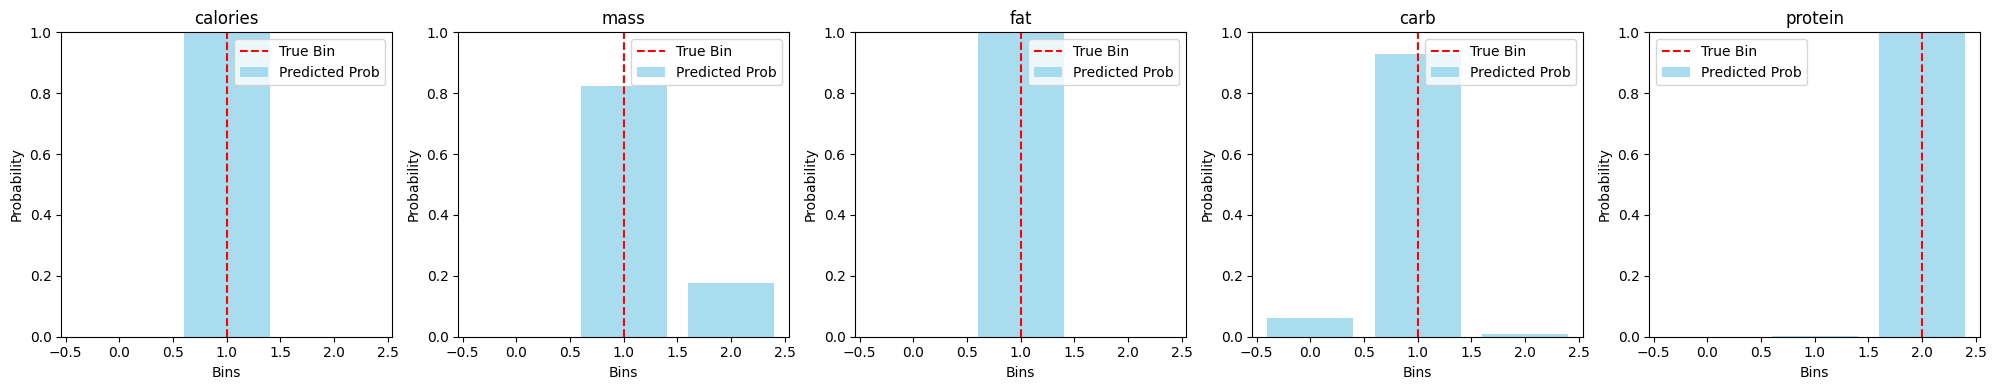

In [40]:
# Plot first 3 validation samples
for idx in range(3):
    plot_sample_prediction(idx, nutrients, all_true_bins, all_pred_probs)